In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import plotly.express as px
import plotly.graph_objects as go

In [ ]:
file_path="/content/drive/MyDrive/loan.csv"

In [ ]:
file_path="/content/drive/MyDrive/loan.csv"

# Load Dataset
df = pd.read_csv(file_path)

# Display First 5 Rows
print(df.head())

# Dataset Information
print(df.info())

# Check Missing Values
print(df.isnull().sum())

/tmp/ipykernel_8450/2207577074.py:4: DtypeWarning: Columns (19,47,55,112,123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


   id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0 NaN        NaN       2500         2500           2500.0   36 months   
1 NaN        NaN      30000        30000          30000.0   60 months   
2 NaN        NaN       5000         5000           5000.0   36 months   
3 NaN        NaN       4000         4000           4000.0   36 months   
4 NaN        NaN      30000        30000          30000.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.56        84.92     C        C1  ...                            NaN   
1     18.94       777.23     D        D2  ...                            NaN   
2     17.97       180.69     D        D1  ...                            NaN   
3     18.94       146.51     D        D2  ...                            NaN   
4     16.14       731.78     C        C4  ...                            NaN   

  hardship_last_payment_amount disbursement_method  debt_settlement_flag  \
0   

In [ ]:
selected_columns = [
    'loan_amnt',      # Correct column for LoanAmount
    'term',           # Correct column for LoanTerm
    'int_rate',       # Correct column for InterestRate
    'annual_inc',     # Correct column for Income
    'emp_length',     # Correct column for MonthsEmployed
    'home_ownership', # Correct column for HasMortgage
    'purpose',        # Correct column for LoanPurpose
    'loan_status'     # Correct column for Default
]

df = df[selected_columns].copy()

In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())
df.dropna(inplace=True)
# Convert 'term' column to numerical format
df['term'] = df['term'].str.replace(' months', '', regex=False).astype(int)


Missing Values:
loan_amnt         0
term              0
int_rate          0
annual_inc        0
emp_length        0
home_ownership    0
purpose           0
loan_status       0
Risk_Level        0
dtype: int64


In [ ]:
print("\nAverage Loan Amount:")
print(df['loan_amnt'].mean())

print("\nAverage Annual Income:")
print(df['annual_inc'].mean())

print("\nInterest Rate Statistics:")
print(df['int_rate'].describe())


Average Loan Amount:
15250.496864114466

Average Annual Income:
79962.63407163644

Interest Rate Statistics:
count    2.113757e+06
mean     1.308560e+01
std      4.828405e+00
min      5.310000e+00
25%      9.490000e+00
50%      1.262000e+01
75%      1.599000e+01
max      3.099000e+01
Name: int_rate, dtype: float64


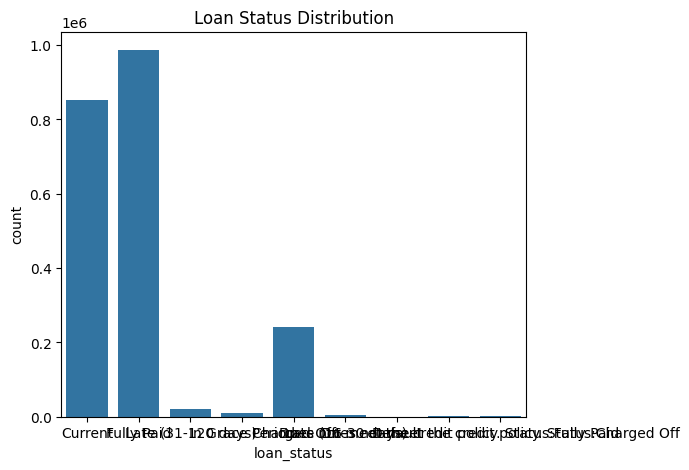


Loan Status Count:
loan_status
Fully Paid                                             986892
Current                                                851216
Charged Off                                            241261
Late (31-120 days)                                      19963
In Grace Period                                          8380
Late (16-30 days)                                        3306
Does not meet the credit policy. Status:Fully Paid       1965
Does not meet the credit policy. Status:Charged Off       746
Default                                                    28
Name: count, dtype: int64


In [ ]:
default_counts = df['loan_status'].value_counts()

plt.figure(figsize=(6,5))
sns.countplot(x='loan_status', data=df)
plt.title("Loan Status Distribution")
plt.show()

print("\nLoan Status Count:")
print(default_counts)

In [ ]:
income_default = df.groupby('loan_status')['annual_inc'].mean()
print("\nIncome vs Loan Status:")
print(income_default)
emp_default = df.groupby('loan_status')['emp_length'].mean()
print("\nEmployment Length vs Loan Status:")
print(emp_default)
home_default = pd.crosstab(df['home_ownership'], df['loan_status'])
print("\nHome Ownership vs Default:")
print(home_default)
purpose_default = pd.crosstab(df['purpose'], df['loan_status'])
print("\nPurpose vs Default:")
print(purpose_default)


Income vs Loan Status:
loan_status
Charged Off                                            72336.779025
Current                                                83096.361530
Default                                                68290.714286
Does not meet the credit policy. Status:Charged Off    69978.537989
Does not meet the credit policy. Status:Fully Paid     72428.589237
Fully Paid                                             79120.676934
In Grace Period                                        83306.043456
Late (16-30 days)                                      83097.471549
Late (31-120 days)                                     79334.523591
Name: annual_inc, dtype: float64

Employment Length vs Loan Status:
loan_status
Charged Off                                            5.861341
Current                                                5.890459
Default                                                5.071429
Does not meet the credit policy. Status:Charged Off    4.603217
Does not meet th

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


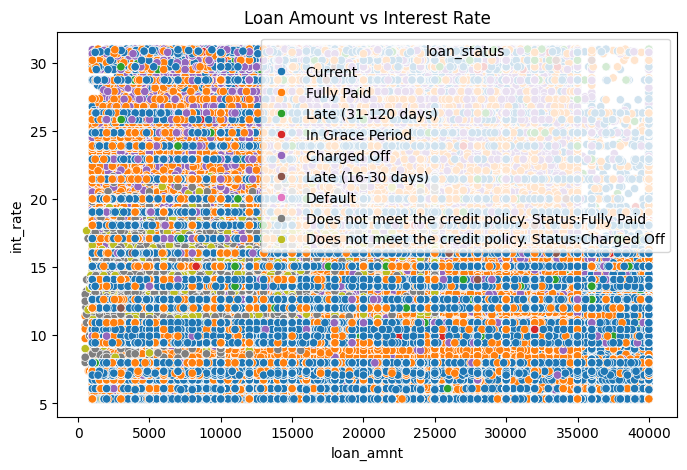

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


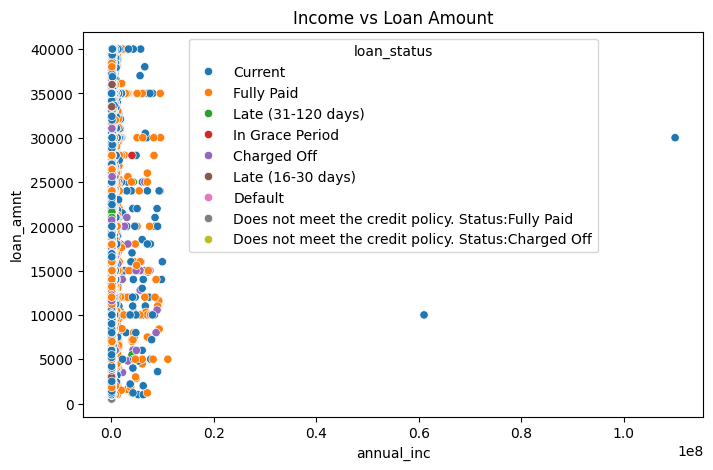

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='loan_amnt', y='int_rate', hue='loan_status', data=df)
plt.title("Loan Amount vs Interest Rate")
plt.show()
plt.figure(figsize=(8,5))
sns.scatterplot(x='annual_inc', y='loan_amnt', hue='loan_status', data=df)
plt.title("Income vs Loan Amount")
plt.show()

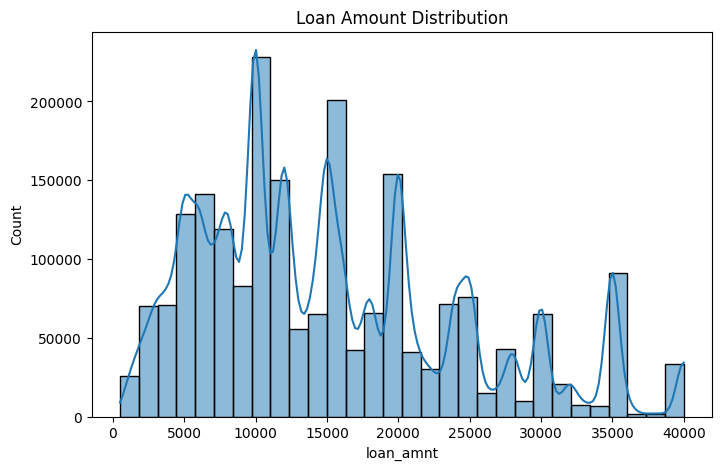

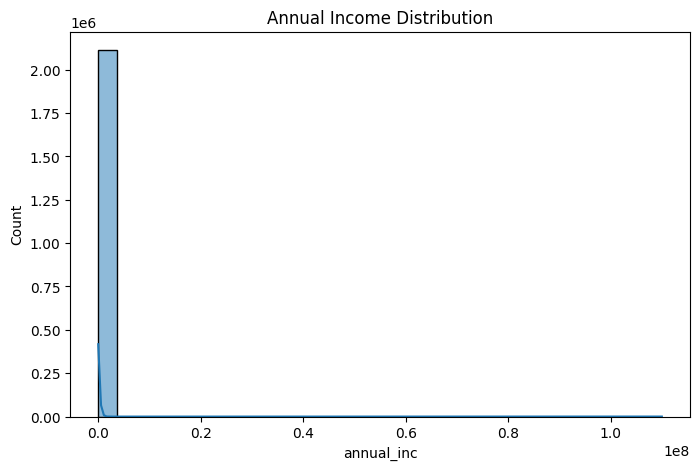

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['loan_amnt'], bins=30, kde=True)
plt.title("Loan Amount Distribution")
plt.show()
plt.figure(figsize=(8,5))
sns.histplot(df['annual_inc'], bins=30, kde=True)
plt.title("Annual Income Distribution")
plt.show()

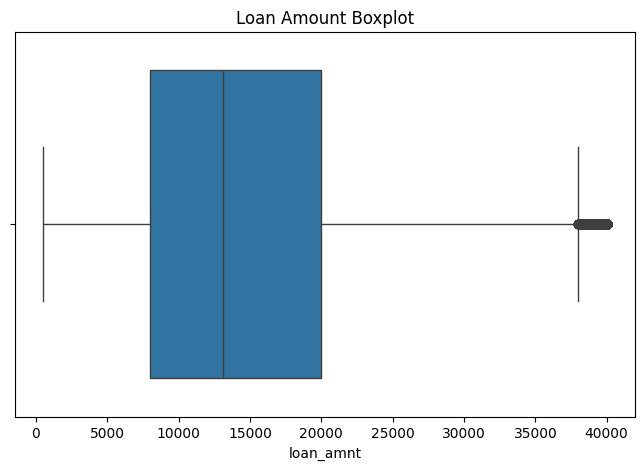

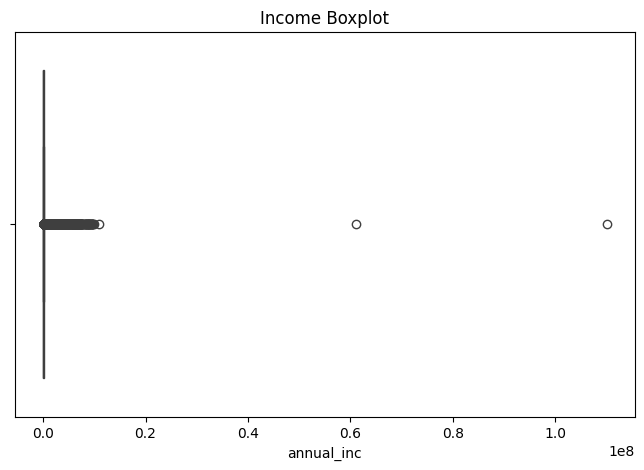

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['loan_amnt'])
plt.title("Loan Amount Boxplot")
plt.show()
plt.figure(figsize=(8,5))
sns.boxplot(x=df['annual_inc'])
plt.title("Income Boxplot")
plt.show()

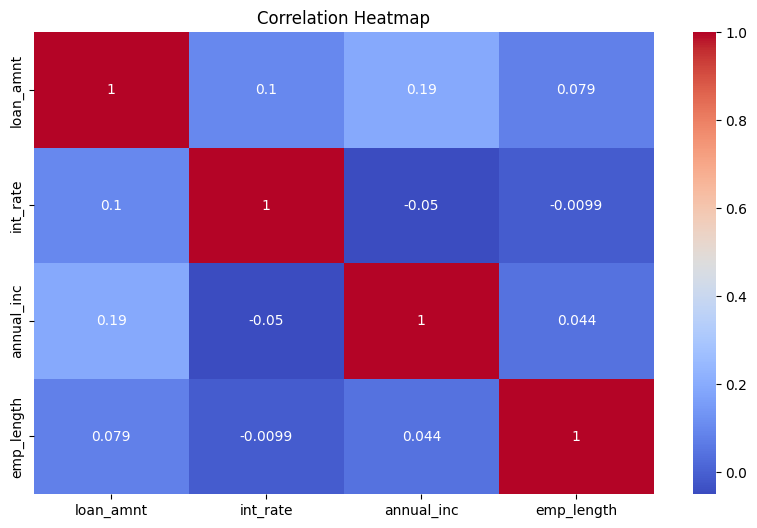

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
def classify_risk(rate):
    if rate < 10:
        return "Low Risk"
    elif rate < 20:
        return "Medium Risk"
    else:
        return "High Risk"

df['Risk_Level'] = df['int_rate'].apply(classify_risk)

print("\nRisk Level Counts:")
print(df['Risk_Level'].value_counts())


Risk Level Counts:
Risk_Level
Medium Risk    1331049
Low Risk        609416
High Risk       173292
Name: count, dtype: int64


In [ ]:
# Ensure 'term' column is numerical before creating X and y
# This step is included here to make the cell robust against execution order issues,
# as df['term'] should already be int after F3MZ9h2d5nxX runs.
if df['term'].dtype == 'object':
    df['term'] = df['term'].str.replace(' months', '', regex=False).astype(int)

X = df[['annual_inc', 'int_rate', 'term']]
y = df['loan_amnt']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Evaluation")
print("----------------------")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)


Model Evaluation
----------------------
R2 Score: 0.179903323262547
MAE: 6558.372997630307
RMSE: 8348.27264546166


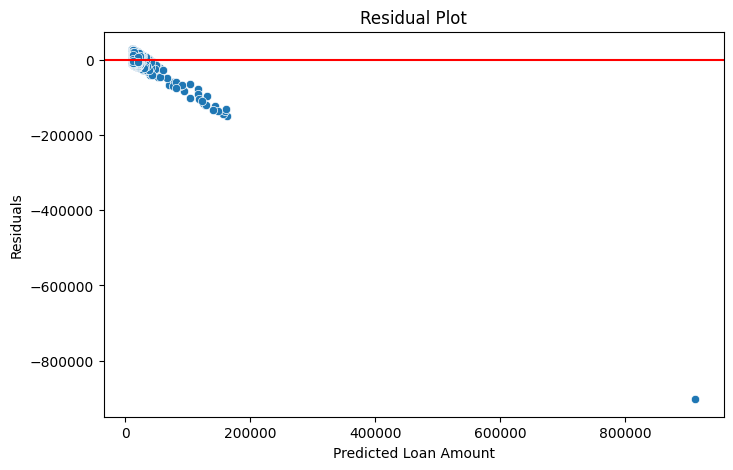

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='red')
plt.title("Residual Plot")
plt.xlabel("Predicted Loan Amount")
plt.ylabel("Residuals")
plt.show()

In [ ]:
fig1 = px.scatter(
    df,
    x='Income',
    y='LoanAmount',
    color='Default',
    title='Income vs Loan Amount'
)

fig1.show()
fig2 = px.histogram(
    df,
    x='LoanAmount',
    color='Default',
    title='Loan Amount Distribution'
)

fig2.show()
fig3 = px.box(
    df,
    x='Default',
    y='InterestRate',
    color='Default',
    title='Interest Rate vs Loan Status'
)

fig3.show()
fig4 = px.bar(
    df,
    x='HasMortgage',
    color='Default',
    title='Default Comparison by Home Ownership'
)

fig4.show()